Telemetry agent workflow: Raw telemetry -->  Understand sensor behaviour --> Validate pre-failure signals --> Build health score --> Validate the score --> Build the predictive tool --> Connect the agent

The purpose of the agent is to check at a machine's sensor data and identify whether the machine is becoming unhealty before it actually fails? 

The notebook uses 4 signals --> voltage, rotational speed, pressure, vibration. It also has historical information 

The goal is to produce an output  like this:
Machine 1
Health Score: 0.3082
Risk Level: High

And eventually an agent can use that result:
Agent --> "Check Machine 1" --> Health tool --> Health Score = 0.3082 --> High risk --> Escalate for priortization

##### Setup

In [1]:
import pandas as pd
import numpy as np
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.2.3
numpy version: 2.1.3


##### Load data

In [2]:
import pandas as pd

# Load all 5 files
telemetry = pd.read_csv("../data/raw/PdM_telemetry.csv") #contains sensor readings
errors = pd.read_csv("../data/raw/PdM_errors.csv")  # Contains historical machine errors
maint = pd.read_csv("../data/raw/PdM_maint.csv")  # Contains maintenance history
failures = pd.read_csv("../data/raw/PdM_failures.csv") #Contains actual failures
machines = pd.read_csv("../data/raw/PdM_machines.csv") #Contains machine details

# Print the shape (rows, columns) of each
print("telemetry:", telemetry.shape)
print("errors:", errors.shape)
print("maintenance:", maint.shape)
print("failures:", failures.shape)
print("machines:", machines.shape)

telemetry: (876100, 6)
errors: (3919, 3)
maintenance: (3286, 3)
failures: (761, 3)
machines: (100, 3)


##### Explore Data

In [3]:
print("=== TELEMETRY ===")
print(telemetry.head())
print("\n=== FAILURES ===")
print(failures.head())
print("\n=== MACHINES ===")
print(machines.head())

=== TELEMETRY ===
              datetime  machineID        volt      rotate    pressure  \
0  2015-01-01 06:00:00          1  176.217853  418.504078  113.077935   
1  2015-01-01 07:00:00          1  162.879223  402.747490   95.460525   
2  2015-01-01 08:00:00          1  170.989902  527.349825   75.237905   
3  2015-01-01 09:00:00          1  162.462833  346.149335  109.248561   
4  2015-01-01 10:00:00          1  157.610021  435.376873  111.886648   

   vibration  
0  45.087686  
1  43.413973  
2  34.178847  
3  41.122144  
4  25.990511  

=== FAILURES ===
              datetime  machineID failure
0  2015-01-05 06:00:00          1   comp4
1  2015-03-06 06:00:00          1   comp1
2  2015-04-20 06:00:00          1   comp2
3  2015-06-19 06:00:00          1   comp4
4  2015-09-02 06:00:00          1   comp4

=== MACHINES ===
   machineID   model  age
0          1  model3   18
1          2  model4    7
2          3  model3    8
3          4  model3    7
4          5  model3    2


##### Convert dates & Look at the machine's first failure

In [4]:
#convert datetime columns to actual datetime type

telemetry['datetime'] = pd.to_datetime(telemetry['datetime'])
failures['datetime'] = pd.to_datetime(failures['datetime'])

#Look for machine 1's first failure
machine1_failure1 = failures[failures['machineID'] == 1].iloc[0]
failure_time = machine1_failure1['datetime']

window = telemetry[
    (telemetry['machineID'] == 1) &
    (telemetry['datetime'] >= failure_time - pd.Timedelta(hours=48)) &
    (telemetry['datetime'] <= failure_time)   
]

print("Failure happened at:", failure_time, "- Component:", machine1_failure1['failure'])
print(window[['datetime', 'volt', 'rotate', 'pressure', 'vibration']])

Failure happened at: 2015-01-05 06:00:00 - Component: comp4
              datetime        volt      rotate    pressure  vibration
48 2015-01-03 06:00:00  177.594089  459.956670   96.651624  52.997327
49 2015-01-03 07:00:00  175.213280  486.494804  104.432962  47.875804
50 2015-01-03 08:00:00  164.341435  568.972310   94.488533  49.023585
51 2015-01-03 09:00:00  171.464292  454.317959   85.246610  47.698464
52 2015-01-03 10:00:00  194.581170  448.360259   98.390618  50.602141
53 2015-01-03 11:00:00  156.866113  405.869840   98.640816  54.698163
54 2015-01-03 12:00:00  171.826400  439.841489   87.874871  55.768097
55 2015-01-03 13:00:00  190.431960  427.675888  116.008404  55.062110
56 2015-01-03 14:00:00  166.480684  487.422676   90.423892  66.764515
57 2015-01-03 15:00:00  154.199258  469.854313   85.755546  47.946793
58 2015-01-03 16:00:00  156.953246  462.024182  106.346718  48.820301
59 2015-01-03 17:00:00  164.148095  429.822144  104.532124  43.788682
60 2015-01-03 18:00:00  157.28

##### Investigate Sensor Behaviour

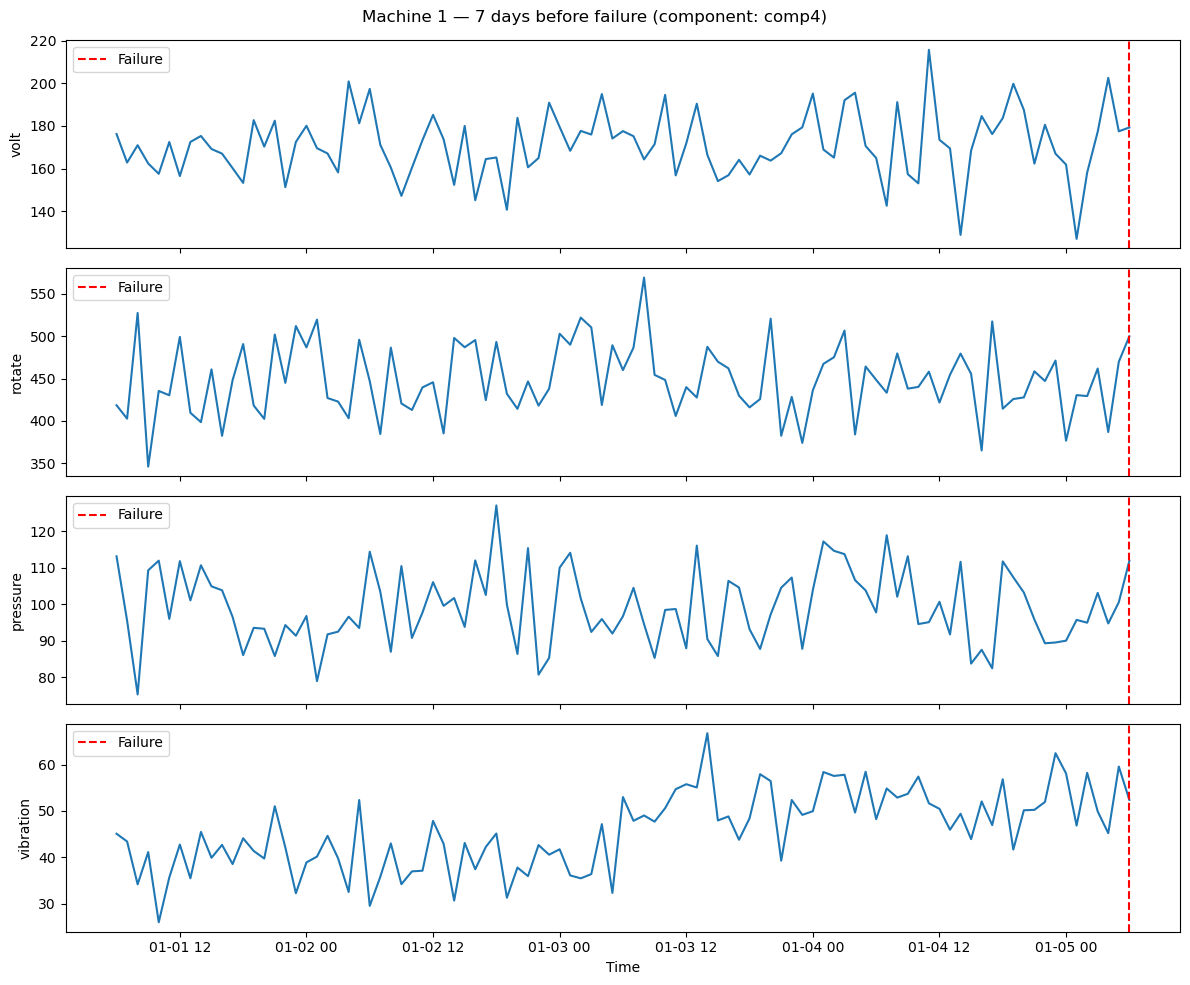

In [5]:
import matplotlib.pyplot as plt

# Look at a wider window: 7 days before the failure, for better trend visibility
window7 = telemetry[
    (telemetry['machineID'] == 1) &
    (telemetry['datetime'] >= failure_time - pd.Timedelta(days=7)) &
    (telemetry['datetime'] <= failure_time)
]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
sensors = ['volt', 'rotate', 'pressure', 'vibration']

for ax, sensor in zip(axes, sensors):
    ax.plot(window7['datetime'], window7[sensor])
    ax.set_ylabel(sensor)
    ax.axvline(failure_time, color='red', linestyle='--', label='Failure')
    ax.legend()

plt.xlabel('Time')
plt.suptitle(f'Machine 1 — 7 days before failure (component: {machine1_failure1["failure"]})')
plt.tight_layout()
plt.show()

In [6]:
# This function checks whether vibration consistently increases before a failure, 
# using three different warning periods, and checks this for every failure in the
# dataset


def check_lead_time(hours_before):
    results = []
    for _, row in failures.iterrows():
        mid = row['machineID']
        ftime = row['datetime']

        before_failure = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(hours=hours_before)) &
            (telemetry['datetime'] < ftime)
        ]
        normal_baseline = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(days=8)) &
            (telemetry['datetime'] < ftime - pd.Timedelta(days=7))
        ]

        if len(before_failure) > 0 and len(normal_baseline) > 0:
            results.append({
                'vibration_before': before_failure['vibration'].mean(),
                'vibration_baseline': normal_baseline['vibration'].mean(),
            })

    df = pd.DataFrame(results)
    df['change_pct'] = (df['vibration_before'] - df['vibration_baseline']) / df['vibration_baseline'] * 100
    pct_increased = (df['change_pct'] > 0).mean() * 100
    print(f"Lead time {hours_before}h: avg change = {df['change_pct'].mean():.2f}%, "
          f"{pct_increased:.1f}% of failures showed increased vibration")

for h in [24, 48, 72]:
    check_lead_time(h)

Lead time 24h: avg change = 6.60%, 61.3% of failures showed increased vibration
Lead time 48h: avg change = 6.72%, 61.2% of failures showed increased vibration
Lead time 72h: avg change = 4.49%, 62.1% of failures showed increased vibration


Inference of the above result:

24 hours before the failure: Vibration increased by 6.60% in 61.3% of failures (Which means 6/10 signal shown increased vibration) 
48 hours before the failure: Vibration increased by 6.72% in 61.2% of failures 
72 hours before the failure: Vibration increased by 4.49% in 62.1% of failures

The 61 to 62 % rate is better than the random chance, suggesting that the vibration contains some useful information

However, 4 out of 10 vibration signals has not shown any increase in vibration.

Probably that the other sensors like - volt, rotate and pressure has to be changed. Combining these signals might also be useful



##### Investigate which sensors are useful

In [7]:
# Identify which sensor show a consistent change before failure. Finding this will
# be useful for building a machine health score / predictive maintenance model. 


def check_lead_time_all_sensors(hours_before):
    sensors = ['volt', 'rotate', 'pressure', 'vibration']
    results = []

    for _, row in failures.iterrows():
        mid = row['machineID']
        ftime = row['datetime']

        before_failure = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(hours=hours_before)) &
            (telemetry['datetime'] < ftime)
        ]
        normal_baseline = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(days=8)) &
            (telemetry['datetime'] < ftime - pd.Timedelta(days=7))
        ]

        if len(before_failure) > 0 and len(normal_baseline) > 0:
            entry = {}
            for sensor in sensors:
                entry[f'{sensor}_before'] = before_failure[sensor].mean()
                entry[f'{sensor}_baseline'] = normal_baseline[sensor].mean()
            results.append(entry)

    df = pd.DataFrame(results)

    print(f"\n=== Lead time: {hours_before}h ===")
    for sensor in sensors:
        change_pct = (df[f'{sensor}_before'] - df[f'{sensor}_baseline']) / df[f'{sensor}_baseline'] * 100
        pct_increased = (change_pct > 0).mean() * 100
        print(f"  {sensor:10s}: avg change = {change_pct.mean():6.2f}%, "
              f"{pct_increased:5.1f}% of failures showed increase")

for h in [24, 48, 72]:
    check_lead_time_all_sensors(h)


=== Lead time: 24h ===
  volt      : avg change =   3.26%,  61.8% of failures showed increase
  rotate    : avg change =  -6.94%,  28.4% of failures showed increase
  pressure  : avg change =   4.94%,  60.1% of failures showed increase
  vibration : avg change =   6.60%,  61.3% of failures showed increase

=== Lead time: 48h ===
  volt      : avg change =   3.26%,  61.7% of failures showed increase
  rotate    : avg change =  -6.92%,  28.1% of failures showed increase
  pressure  : avg change =   5.00%,  60.7% of failures showed increase
  vibration : avg change =   6.72%,  61.2% of failures showed increase

=== Lead time: 72h ===
  volt      : avg change =   2.21%,  62.1% of failures showed increase
  rotate    : avg change =  -4.70%,  27.5% of failures showed increase
  pressure  : avg change =   3.39%,  61.8% of failures showed increase
  vibration : avg change =   4.49%,  62.1% of failures showed increase


Key findings: Sensor behaviour before failure

We analyzed the four sensors to understand how they change before a machine failure:
Rotate decreases in approxmiately 72.5% of the failures 
Vibration increases approx 62% of failures
Volt increases approx 62% of failures
pressure increases approx by 62% of failures

Rotate tend to decresae while vibration, volt and pressure tend to increase before failure

The above suggests that multiple signals contains useful information about warning of failure. Combining these signals should provide a more reliable machine health score rather than a single sensor  


In [8]:
# Volatility check - Lets analyze the signals over 24, 48 and 72 hours before failure to see if 
# increased volatility provides an additional warning signal 

def check_volatility(hours_before):
    sensors = ['volt', 'rotate', 'pressure', 'vibration']
    results = []

    for _, row in failures.iterrows():
        mid = row['machineID']
        ftime = row['datetime']

        before_failure = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(hours=hours_before)) &
            (telemetry['datetime'] < ftime)
        ]
        normal_baseline = telemetry[
            (telemetry['machineID'] == mid) &
            (telemetry['datetime'] >= ftime - pd.Timedelta(days=8)) &
            (telemetry['datetime'] < ftime - pd.Timedelta(days=7))
        ]

        if len(before_failure) > 1 and len(normal_baseline) > 1:
            entry = {}
            for sensor in sensors:
                # .std() = standard deviation = how spread out / erratic the readings are
                entry[f'{sensor}_before_std'] = before_failure[sensor].std()
                entry[f'{sensor}_baseline_std'] = normal_baseline[sensor].std()
            results.append(entry)

    df = pd.DataFrame(results)

    print(f"\n=== Volatility check — Lead time: {hours_before}h ===")
    for sensor in sensors:
        change_pct = (df[f'{sensor}_before_std'] - df[f'{sensor}_baseline_std']) / df[f'{sensor}_baseline_std'] * 100
        pct_increased = (change_pct > 0).mean() * 100
        print(f"  {sensor:10s}: avg volatility change = {change_pct.mean():6.2f}%, "
              f"{pct_increased:5.1f}% of failures showed MORE erratic readings")

for h in [24, 48, 72]:
    check_volatility(h)



=== Volatility check — Lead time: 24h ===
  volt      : avg volatility change =   2.48%,  50.8% of failures showed MORE erratic readings
  rotate    : avg volatility change =   1.85%,  48.5% of failures showed MORE erratic readings
  pressure  : avg volatility change =   2.04%,  49.7% of failures showed MORE erratic readings
  vibration : avg volatility change =   3.11%,  53.2% of failures showed MORE erratic readings

=== Volatility check — Lead time: 48h ===
  volt      : avg volatility change =   3.48%,  52.5% of failures showed MORE erratic readings
  rotate    : avg volatility change =   2.89%,  49.2% of failures showed MORE erratic readings
  pressure  : avg volatility change =   4.40%,  53.3% of failures showed MORE erratic readings
  vibration : avg volatility change =   4.14%,  54.5% of failures showed MORE erratic readings

=== Volatility check — Lead time: 72h ===
  volt      : avg volatility change =   8.93%,  64.2% of failures showed MORE erratic readings
  rotate    : av

Volatility check - key findings:

The voltatility signal was inconsistant. It was only strong in 72 hours. We will exclude volalitly from the health score fo now

##### Smooth noisy sensor reading

In [9]:
# Indivudual hourly readings are noisy. So we will calculate 24 hour rolling average

# Sort so rolling calculations happen in correct time order per machine
telemetry_sorted = telemetry.sort_values(['machineID', 'datetime']).reset_index(drop=True)

# For each machine, calculate a 24-hour rolling average for each sensor
sensors = ['volt', 'rotate', 'pressure', 'vibration']

for sensor in sensors:
    telemetry_sorted[f'{sensor}_roll24'] = (
        telemetry_sorted.groupby('machineID')[sensor]
        .transform(lambda x: x.rolling(window=24, min_periods=12).mean())
    )

print(telemetry_sorted[['datetime', 'machineID'] + [f'{s}_roll24' for s in sensors]].head(30))

              datetime  machineID  volt_roll24  rotate_roll24  \
0  2015-01-01 06:00:00          1          NaN            NaN   
1  2015-01-01 07:00:00          1          NaN            NaN   
2  2015-01-01 08:00:00          1          NaN            NaN   
3  2015-01-01 09:00:00          1          NaN            NaN   
4  2015-01-01 10:00:00          1          NaN            NaN   
5  2015-01-01 11:00:00          1          NaN            NaN   
6  2015-01-01 12:00:00          1          NaN            NaN   
7  2015-01-01 13:00:00          1          NaN            NaN   
8  2015-01-01 14:00:00          1          NaN            NaN   
9  2015-01-01 15:00:00          1          NaN            NaN   
10 2015-01-01 16:00:00          1          NaN            NaN   
11 2015-01-01 17:00:00          1   166.967614     429.934546   
12 2015-01-01 18:00:00          1   165.920374     434.606729   
13 2015-01-01 19:00:00          1   167.121712     433.434766   
14 2015-01-01 20:00:00   

##### Calculate deviation from the normal (Scoring Logic)

In [10]:
# Step A: Calculate each machine's own "normal" baseline (overall average across its full history)
machine_baselines = telemetry_sorted.groupby('machineID')[sensors].mean()
machine_baselines.columns = [f'{s}_machine_avg' for s in sensors]

# Step B: Merge these baselines back onto every row
telemetry_sorted = telemetry_sorted.merge(machine_baselines, on='machineID', how='left')

# Step C: Calculate how far each rolling average deviates from that machine's normal baseline
telemetry_sorted['vibration_dev'] = (telemetry_sorted['vibration_roll24'] - telemetry_sorted['vibration_machine_avg']) / telemetry_sorted['vibration_machine_avg']
telemetry_sorted['volt_dev'] = (telemetry_sorted['volt_roll24'] - telemetry_sorted['volt_machine_avg']) / telemetry_sorted['volt_machine_avg']
telemetry_sorted['pressure_dev'] = (telemetry_sorted['pressure_roll24'] - telemetry_sorted['pressure_machine_avg']) / telemetry_sorted['pressure_machine_avg']
telemetry_sorted['rotate_dev'] = (telemetry_sorted['rotate_roll24'] - telemetry_sorted['rotate_machine_avg']) / telemetry_sorted['rotate_machine_avg']

# Step D: Combine into a single health risk score
# vibration/volt/pressure: higher deviation = more risk (positive sign)
# rotate: LOWER value = more risk, so we flip its sign
telemetry_sorted['health_risk_score'] = (
    telemetry_sorted['vibration_dev'] +
    telemetry_sorted['volt_dev'] +
    telemetry_sorted['pressure_dev'] -
    telemetry_sorted['rotate_dev']
)

print(telemetry_sorted[['datetime', 'machineID', 'health_risk_score']].dropna().head(10))
print("\nScore range:", telemetry_sorted['health_risk_score'].min(), "to", telemetry_sorted['health_risk_score'].max())

              datetime  machineID  health_risk_score
11 2015-01-01 17:00:00          1          -0.002631
12 2015-01-01 18:00:00          1          -0.022464
13 2015-01-01 19:00:00          1          -0.015102
14 2015-01-01 20:00:00          1          -0.014048
15 2015-01-01 21:00:00          1          -0.009882
16 2015-01-01 22:00:00          1          -0.017358
17 2015-01-01 23:00:00          1          -0.040566
18 2015-01-02 00:00:00          1          -0.044586
19 2015-01-02 01:00:00          1          -0.062257
20 2015-01-02 02:00:00          1          -0.057751

Score range: -0.23293416039167242 to 0.745295243685012


##### Create health-risk score

In [11]:
# For each failure, check the health_risk_score in the 24h before failure vs a normal baseline week
score_results = []

for _, row in failures.iterrows():
    mid = row['machineID']
    ftime = row['datetime']

    before_failure = telemetry_sorted[
        (telemetry_sorted['machineID'] == mid) &
        (telemetry_sorted['datetime'] >= ftime - pd.Timedelta(hours=24)) &
        (telemetry_sorted['datetime'] < ftime)
    ]
    normal_baseline = telemetry_sorted[
        (telemetry_sorted['machineID'] == mid) &
        (telemetry_sorted['datetime'] >= ftime - pd.Timedelta(days=8)) &
        (telemetry_sorted['datetime'] < ftime - pd.Timedelta(days=7))
    ]

    if len(before_failure) > 0 and len(normal_baseline) > 0:
        score_results.append({
            'machineID': mid,
            'score_before_failure': before_failure['health_risk_score'].mean(),
            'score_normal_baseline': normal_baseline['health_risk_score'].mean(),
        })

score_df = pd.DataFrame(score_results)

print("Number of failures analyzed:", len(score_df))
print("Average score in 24h before failure:", score_df['score_before_failure'].mean())
print("Average score during normal baseline:", score_df['score_normal_baseline'].mean())
print("\n% of failures where score was HIGHER before failure than normal:",
      (score_df['score_before_failure'] > score_df['score_normal_baseline']).mean() * 100, "%")

Number of failures analyzed: 726
Average score in 24h before failure: 0.20467132184117254
Average score during normal baseline: -0.010233119434291255

% of failures where score was HIGHER before failure than normal: 93.66391184573003 %


Interpretation:

Low Score = Machine looks normal
High score = Machine is unhealthy

On a normal day - health score is -0.01
Before 24 hours - health score is 0.20 

So the score was much higher before the machine failed. 


Vibration alone gave a failure warning of 62% and rotate gave a warning of 72%. Combining these two gave a warning for 93.66%

Key take away:

By combining the four sensor signals and comparing them with each machine's normal behavior, our health score detected elevated risk before failure in 93.66% of the analyzed failures.



##### Validate the score against historical failures

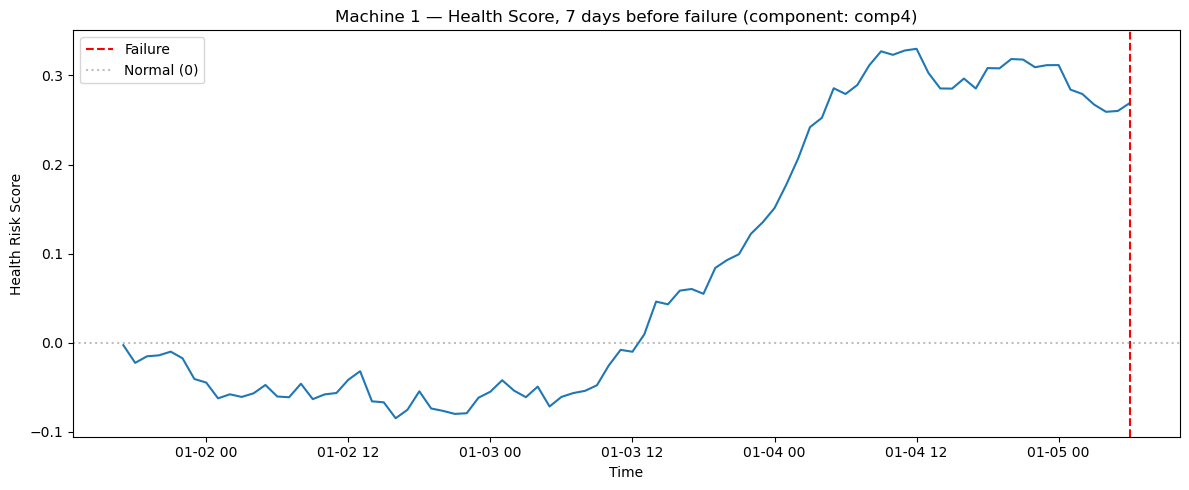

In [12]:
import matplotlib.pyplot as plt

# Let's look at machine 1's health score around its first real failure again
machine1_failure1 = failures[failures['machineID'] == 1].iloc[0]
failure_time = machine1_failure1['datetime']

window = telemetry_sorted[
    (telemetry_sorted['machineID'] == 1) &
    (telemetry_sorted['datetime'] >= failure_time - pd.Timedelta(days=7)) &
    (telemetry_sorted['datetime'] <= failure_time)
]

plt.figure(figsize=(12, 5))
plt.plot(window['datetime'], window['health_risk_score'])
plt.axvline(failure_time, color='red', linestyle='--', label='Failure')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Normal (0)')
plt.ylabel('Health Risk Score')
plt.xlabel('Time')
plt.title(f'Machine 1 — Health Score, 7 days before failure (component: {machine1_failure1["failure"]})')
plt.legend()
plt.tight_layout()
plt.show()

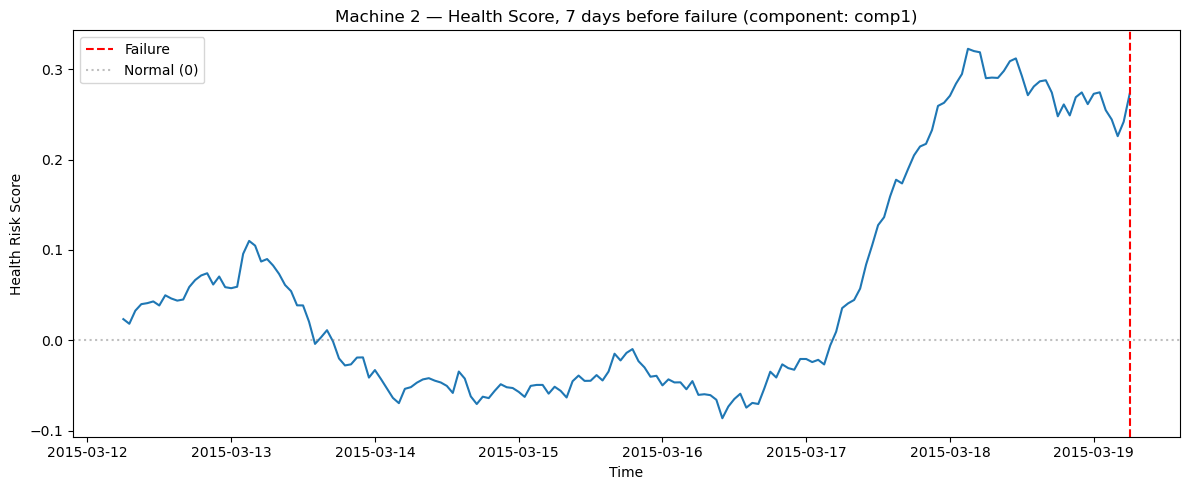

In [13]:
import matplotlib.pyplot as plt

# Let's look at machine 2's health score around its first real failure again
machine2_failure1 = failures[failures['machineID'] == 2].iloc[0]
failure_time = machine2_failure1['datetime']

window = telemetry_sorted[
    (telemetry_sorted['machineID'] == 2) &
    (telemetry_sorted['datetime'] >= failure_time - pd.Timedelta(days=7)) &
    (telemetry_sorted['datetime'] <= failure_time)
]

plt.figure(figsize=(12, 5))
plt.plot(window['datetime'], window['health_risk_score'])
plt.axvline(failure_time, color='red', linestyle='--', label='Failure')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Normal (0)')
plt.ylabel('Health Risk Score')
plt.xlabel('Time')
plt.title(f'Machine 2 — Health Score, 7 days before failure (component: {machine2_failure1["failure"]})')
plt.legend()
plt.tight_layout()
plt.show()

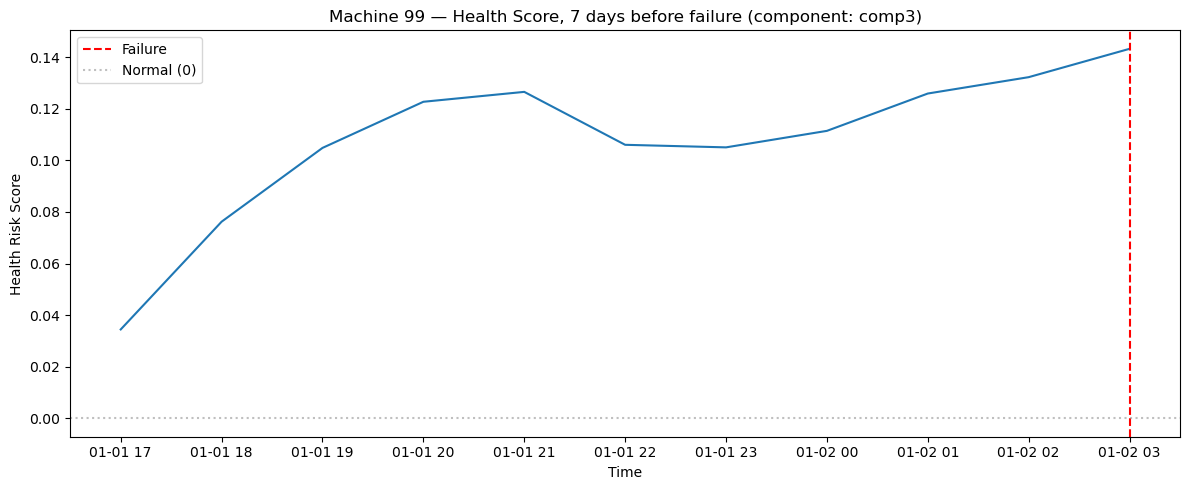

In [14]:
import matplotlib.pyplot as plt

# Let's look at machine 99's health score around its first real failure again
machine99_failure1 = failures[failures['machineID'] == 99].iloc[0]
failure_time = machine99_failure1['datetime']

window = telemetry_sorted[
    (telemetry_sorted['machineID'] == 99) &
    (telemetry_sorted['datetime'] >= failure_time - pd.Timedelta(days=7)) &
    (telemetry_sorted['datetime'] <= failure_time)
]

plt.figure(figsize=(12, 5))
plt.plot(window['datetime'], window['health_risk_score'])
plt.axvline(failure_time, color='red', linestyle='--', label='Failure')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Normal (0)')
plt.ylabel('Health Risk Score')
plt.xlabel('Time')
plt.title(f'Machine 99 — Health Score, 7 days before failure (component: {machine99_failure1["failure"]})')
plt.legend()
plt.tight_layout()
plt.show()

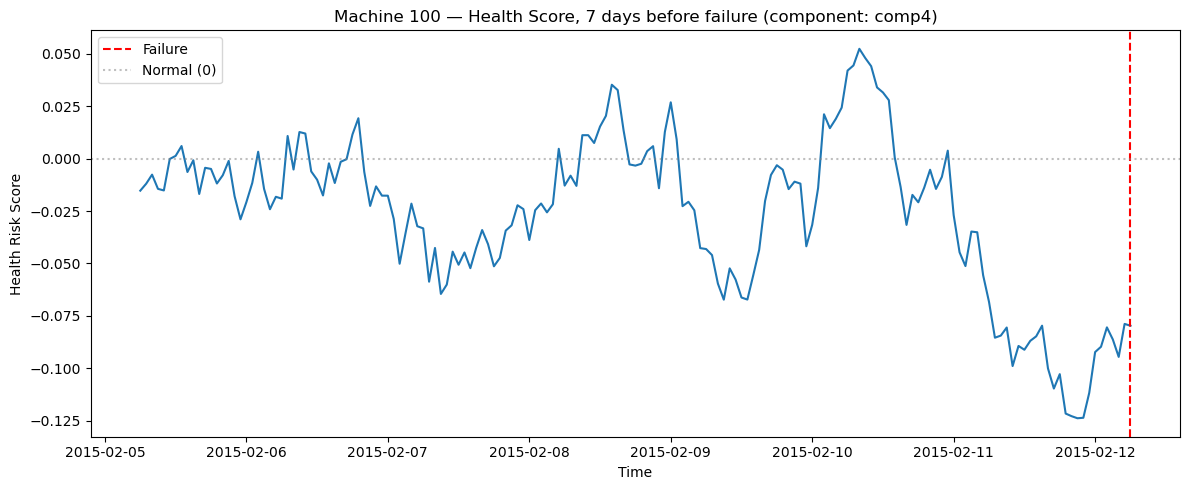

In [15]:
import matplotlib.pyplot as plt

# Let's look at machine 100's health score around its first real failure again
machine100_failure1 = failures[failures['machineID'] == 100].iloc[0]
failure_time = machine100_failure1['datetime']

window = telemetry_sorted[
    (telemetry_sorted['machineID'] == 1) &
    (telemetry_sorted['datetime'] >= failure_time - pd.Timedelta(days=7)) &
    (telemetry_sorted['datetime'] <= failure_time)
]

plt.figure(figsize=(12, 5))
plt.plot(window['datetime'], window['health_risk_score'])
plt.axvline(failure_time, color='red', linestyle='--', label='Failure')
plt.axhline(0, color='gray', linestyle=':', alpha=0.5, label='Normal (0)')
plt.ylabel('Health Risk Score')
plt.xlabel('Time')
plt.title(f'Machine 100 — Health Score, 7 days before failure (component: {machine1_failure1["failure"]})')
plt.legend()
plt.tight_layout()
plt.show()

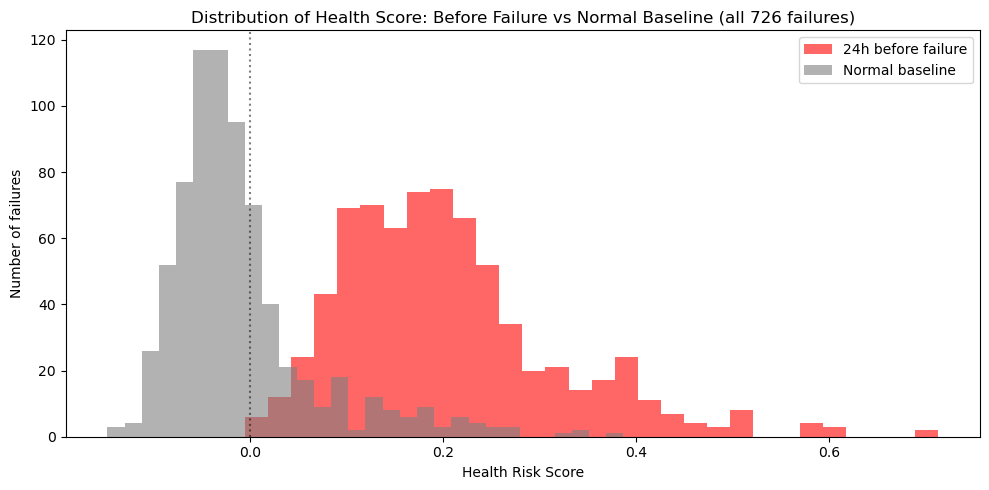

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(score_df['score_before_failure'], bins=30, alpha=0.6, label='24h before failure', color='red')
plt.hist(score_df['score_normal_baseline'], bins=30, alpha=0.6, label='Normal baseline', color='gray')
plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.xlabel('Health Risk Score')
plt.ylabel('Number of failures')
plt.title('Distribution of Health Score: Before Failure vs Normal Baseline (all 726 failures)')
plt.legend()
plt.tight_layout()
plt.show()

##### Test healthy machines

In [17]:

#	Does the tool correctly say "low risk" when a machine is actually healthy? 
import sys
sys.path.append('../src/tools')
from predict_failure_risk import compute_health_scores, predict_failure_risk

# Run the full calculation once
telemetry_scored = compute_health_scores(telemetry)

# Test the tool function on a couple of machines
print(predict_failure_risk(1, telemetry_scored))
print(predict_failure_risk(2, telemetry_scored))
print(predict_failure_risk(100, telemetry_scored))

{'machine_id': 1, 'health_score': np.float64(-0.061), 'risk_level': 'low', 'as_of': Timestamp('2016-01-01 06:00:00')}
{'machine_id': 2, 'health_score': np.float64(-0.0086), 'risk_level': 'low', 'as_of': Timestamp('2016-01-01 06:00:00')}
{'machine_id': 100, 'health_score': np.float64(-0.0065), 'risk_level': 'low', 'as_of': Timestamp('2016-01-01 06:00:00')}


##### Test a machine shortly before failure

In [18]:
# Test the tool at a specific point in time - right before Machine 1's first known failure
machine1_failure1 = failures[failures['machineID'] == 1].iloc[0]
failure_time = machine1_failure1['datetime']

print("Real failure happened at:", failure_time, "- Component:", machine1_failure1['failure'])
print("\nChecking risk 12 hours before that failure:")
print(predict_failure_risk(1, telemetry_scored, as_of=failure_time - pd.Timedelta(hours=12)))

Real failure happened at: 2015-01-05 06:00:00 - Component: comp4

Checking risk 12 hours before that failure:
{'machine_id': 1, 'health_score': np.float64(0.3082), 'risk_level': 'high', 'as_of': Timestamp('2015-01-04 18:00:00')}


##### Live interactive demo
Pick any machine and timestamp to see its live health score.

In [19]:
import ipywidgets as widgets
from IPython.display import display

machine_dropdown = widgets.Dropdown(
    options=sorted(telemetry_scored['machineID'].unique()),
    description='Machine:'
)

date_slider = widgets.SelectionSlider(
    options=sorted(telemetry_scored['datetime'].unique()),
    description='As of:',
    layout=widgets.Layout(width='500px')
)

output = widgets.Output()

def run_demo(change=None):
    output.clear_output()
    with output:
        result = predict_failure_risk(
            machine_dropdown.value,
            telemetry_scored,
            as_of=pd.Timestamp(date_slider.value)
        )
        print(result)

machine_dropdown.observe(run_demo, names='value')
date_slider.observe(run_demo, names='value')

display(machine_dropdown, date_slider, output)
run_demo()

Dropdown(description='Machine:', options=(np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.…

SelectionSlider(description='As of:', layout=Layout(width='500px'), options=(Timestamp('2015-01-01 06:00:00'),…

Output()

"The agent doesn't directly perform the predictive-maintenance calculation. I encapsulate the analytical workflow as a tool. The tool takes raw telemetry, calculates rolling sensor behavior, compares it against the machine's normal baseline, generates a health-risk score, and translates that score into a low, medium, or high risk level. The agent simply invokes the tool when it needs to assess a machine and then uses the structured result for its next decision."

                 AGENT
                   │
                   │ calls
                   ▼
        ┌──────────────────────┐
        │ predict_failure_risk │
        │        TOOL          │
        └──────────┬───────────┘
                   │
                   ▼
          ┌─────────────────┐
          │ Rolling averages│
          └────────┬────────┘
                   ▼
          ┌─────────────────┐
          │ Machine baseline│
          └────────┬────────┘
                   ▼
          ┌─────────────────┐
          │    Deviations   │
          └────────┬────────┘
                   ▼
          ┌─────────────────┐
          │  Health score   │
          └────────┬────────┘
                   ▼
             Low / Medium /
                 High

##### Agent tool calling



In [20]:
import sys
sys.path.append('../src/agents')
from telemetry_health_agent import check_machine_health

# Re-test the same pre-failure scenario from earlier, through the agent this time
print(check_machine_health(2, telemetry_scored, as_of=failure_time - pd.Timedelta(hours=12)))

{'machine_id': 2, 'health_score': np.float64(0.0346), 'risk_level': 'low', 'as_of': Timestamp('2015-01-04 18:00:00'), 'recommended_next_step': 'no_action_needed'}


##### Prioritization Agent

##### Objective
Understand how historical failures are distributed across different machine models and components before calculating reliability metrics such as MTBF.

##### What the code does

The `failures` dataset contains information about failure events, including the `machineID` and failed `component`. The `machines` dataset contains information about each machine, including its `model`.

First, we merge the two datasets using `machineID` so that every failure event can be associated with its machine model.

We then analyze:

1. **Failures by model** – identifies how many failure events occurred for each machine model.
2. **Failures by component** – identifies which components have the highest number of recorded failures.
3. **Failures by model and component** – identifies which component failures are most common within each machine model.


### Why this is important

This is an **exploratory analysis step**, not yet the final MTBF calculation. It helps us identify the major historical failure patterns that will be used in the next stage of reliability analysis.

For example, if a particular model has a high number of failures for a particular component, that model–component combination may require further investigation and may have a higher historical failure rate.

### Analysis Flow

`Failure Records`  
↓  
`Merge with Machine Information`  
↓  
`Identify Machine Model`  
↓  
`Count Failures by Model`  
↓  
`Count Failures by Component`  
↓  
`Count Failures by Model + Component`  
↓  
`Identify Important Failure Patterns`  
↓  
`Calculate Reliability / MTBF Statistics`

> **Key takeaway:** This step answers **"What has historically failed, and where?"** before we try to answer **"How frequently does it fail?"** and calculate MTBF.

In [21]:
# Merge failures with machine info to see model + component failure pattern 
pd.set_option('display.max_rows', None)
failures_with_model = failures.merge(machines, on='machineID')
print("Failures by Model:")
print(failures_with_model.groupby('model').size())

print('\nFailures by Component:')
print(failures_with_model['failure'].value_counts())

print("\nFailures by Model and Component:")
pd.set_option('display.max_rows', None)
print(failures_with_model.groupby(['model', 'failure']).size())




Failures by Model:
model
model1    189
model2    168
model3    221
model4    183
dtype: int64

Failures by Component:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Failures by Model and Component:
model   failure
model1  comp1      33
        comp2      46
        comp3      68
        comp4      42
model2  comp1      30
        comp2      41
        comp3      63
        comp4      34
model3  comp1      68
        comp2      89
        comp4      64
model4  comp1      61
        comp2      83
        comp4      39
dtype: int64


##### Calculation of average time between failures

In [22]:
def calculate_mtbf_stats(failures_df, machines_df):
    """
    For each model + component combination, calculate the average time
    between failures (MTBF) based on real historical failure records.
    """
    merged = failures_df.merge(machines_df, on='machineID')
    merged = merged.sort_values(['model', 'failure', 'datetime'])

    mtbf_records = []

    for (model, component), group in merged.groupby(['model', 'failure']):
        dates = group['datetime'].sort_values()
        if len(dates) > 1:
            # Time gaps between consecutive failures of this model+component
            gaps = dates.diff().dropna()
            avg_gap_days = gaps.mean().total_seconds() / 86400
            mtbf_records.append({
                'model': model,
                'component': component,
                'num_failures_observed': len(dates),
                'avg_days_between_failures': round(avg_gap_days, 1)
            })

    return pd.DataFrame(mtbf_records)

mtbf_stats = calculate_mtbf_stats(failures, machines)
print(mtbf_stats.sort_values('avg_days_between_failures'))

     model component  num_failures_observed  avg_days_between_failures
9   model3     comp2                     89                        3.9
12  model4     comp2                     83                        4.3
2   model1     comp3                     68                        5.2
8   model3     comp1                     68                        5.4
10  model3     comp4                     64                        5.7
6   model2     comp3                     63                        5.8
11  model4     comp1                     61                        6.0
1   model1     comp2                     46                        7.9
3   model1     comp4                     42                        8.7
5   model2     comp2                     41                        9.0
13  model4     comp4                     39                        9.1
7   model2     comp4                     34                       11.0
0   model1     comp1                     33                       11.2
4   mo

##### Tool calling for priotization agent

In [23]:
import sys
sys.path.append('../src/tools')
sys.path.append('../src/agents')
from get_failure_rate_stats import calculate_mtbf_stats
from prioritization_agent import prioritize_machine
from telemetry_health_agent import check_machine_health

# Build the MTBF table once
mtbf_table = calculate_mtbf_stats(failures, machines)

# Get machine 1's model
machine1_model = machines[machines['machineID'] == 1]['model'].values[0]

# Test: check health right before the known failure, then prioritize
health_result = check_machine_health(1, telemetry_scored, as_of=failure_time - pd.Timedelta(hours=12))
priority_result = prioritize_machine(1, machine1_model, health_result, mtbf_table)

print("Health check:", health_result)
print("\nPrioritization:", priority_result)

Health check: {'machine_id': 1, 'health_score': np.float64(0.3082), 'risk_level': 'high', 'as_of': Timestamp('2015-01-04 18:00:00'), 'recommended_next_step': 'escalate_to_prioritization'}

Prioritization: {'machine_id': 1, 'model': 'model3', 'health_score': np.float64(0.3082), 'risk_level': 'high', 'most_likely_component': 'comp2', 'urgency_score': np.float64(2.3708)}


##### Tool calling to test the test priorization acoross many machines

In [24]:
# Test prioritization across a handful of machines, at the same point in time
test_machines = [1, 2, 5, 42, 100]
priority_results = []

for mid in test_machines:
    model = machines[machines['machineID'] == mid]['model'].values[0]
    health = check_machine_health(mid, telemetry_scored, as_of=pd.Timestamp('2015-06-01 06:00:00'))
    priority = prioritize_machine(mid, model, health, mtbf_table)
    priority_results.append(priority)

priority_df = pd.DataFrame(priority_results).sort_values('urgency_score', ascending=False)
print(priority_df)

   machine_id   model  health_score risk_level most_likely_component  \
4         100  model4        0.2571       high                 comp2   
1           2  model4        0.0273        low                 comp2   
0           1  model3        0.0122        low                 comp2   
2           5  model3       -0.0613        low                 comp2   
3          42  model1       -0.0969        low                 comp3   

   urgency_score  
4         1.7937  
1         0.1905  
0         0.0938  
2        -0.4715  
3        -0.5590  


##### Designing a knowledge library

Good to pin this down clearly before we build it.

###### Plain-language definition

The **Knowledge Library** is a collection of real past cases — one entry for every actual historical failure in the dataset — stored in a way that lets the system **search by similarity**, not just exact lookup.

Think of it like this: imagine a senior maintenance engineer who's been at a plant for 10 years. When a new problem comes up, they don't start from scratch — they think, *"this reminds me of what happened with Machine 12 back in March."* That engineer's memory of past cases **is** the knowledge library. We're building a digital version of that memory, made entirely from real recorded failures.

###### Concretely, in our system

Each entry in the library — what we're calling a "case record" — contains:
- Which machine and model failed
- Which component failed
- When it happened
- What the sensor readings looked like in the hours before (the "signature" of that failure)
- A plain-language description of all of the above

We're building **761 of these** (roughly — however many have valid data), one per real historical failure. That's the library.

###### Why it needs to be "searchable by similarity," not just a list

A plain list or spreadsheet of these 761 cases isn't useful on its own — we need to be able to ask, *"Machine 42 is showing this sensor pattern right now — which past cases looked similar?"* That's a fuzzy, pattern-matching question, not something you can answer with a simple filter like `WHERE machine_id = 42`.

This is exactly why we're using **ChromaDB** — it converts each case's description into a set of numbers (an "embedding") that captures the pattern of that case, so it can mathematically compare "how similar is this new situation to each of the 761 stored cases" and return the closest matches.

###### Where this fits in the bigger picture

| Concept | What it is |
|---|---|
| **Case records**  | The raw content — 761 real failure summaries |
| **ChromaDB**  | The searchable database that stores these case records as embeddings |
| **Knowledge Library** | The two together — content + searchability |
| **Case Retrieval Agent**  | The agent that actually queries this library when a new machine shows risk |
| **Reasoning Agent**  | Uses what the Retrieval Agent finds to write a grounded explanation |

**In one line:** the Knowledge Library is the system's memory of real past failures, built so it can be searched by "what does this look like," not just "give me an exact match" — and it's what makes tomorrow's diagnosis grounded in real evidence rather than the LLM guessing.



In [25]:
def build_case_records(failures_df, telemetry_scored_df, machines_df, hours_before=24):
    """
    For each real historical failure, build a 'case record' capturing:
    - which machine, model, and component failed
    - when it happened
    - what the sensor signature looked like in the hours before failure
    This becomes the searchable knowledge library.
    """
    cases = []

    for _, row in failures_df.iterrows():
        mid = row['machineID']
        ftime = row['datetime']
        component = row['failure']

        model = machines_df[machines_df['machineID'] == mid]['model'].values[0]

        window = telemetry_scored_df[
            (telemetry_scored_df['machineID'] == mid) &
            (telemetry_scored_df['datetime'] >= ftime - pd.Timedelta(hours=hours_before)) &
            (telemetry_scored_df['datetime'] < ftime)
        ]

        if len(window) == 0:
            continue

        # Capture the average sensor deviations in the window before failure
        avg_health_score = window['health_risk_score'].mean()
        avg_vibration_dev = window['vibration_dev'].mean()
        avg_volt_dev = window['volt_dev'].mean()
        avg_pressure_dev = window['pressure_dev'].mean()
        avg_rotate_dev = window['rotate_dev'].mean()

        # A natural-language description built from real numbers 
        description = (
            f"Machine {mid} (model {model}) experienced a {component} failure on {ftime.date()}. "
            f"In the {hours_before} hours prior, vibration deviated {avg_vibration_dev*100:.1f}% from normal, "
            f"voltage {avg_volt_dev*100:.1f}%, pressure {avg_pressure_dev*100:.1f}%, "
            f"and rotation {avg_rotate_dev*100:.1f}%. Combined health risk score averaged {avg_health_score:.3f}."
        )

        cases.append({
            'case_id': f"machine{mid}_{component}_{ftime.strftime('%Y%m%d_%H%M%S')}",
            'machine_id': mid,
            'model': model,
            'component': component,
            'failure_datetime': str(ftime),
            'avg_health_score': round(avg_health_score, 4),
            'avg_vibration_dev': round(avg_vibration_dev, 4),
            'avg_volt_dev': round(avg_volt_dev, 4),
            'avg_pressure_dev': round(avg_pressure_dev, 4),
            'avg_rotate_dev': round(avg_rotate_dev, 4),
            'description': description
        })

    return pd.DataFrame(cases)

case_records = build_case_records(failures, telemetry_scored, machines)
print(f"Total case records built: {len(case_records)}")
print("\nSample case:")
print(case_records.iloc[0]['description'])
print("\n", case_records.iloc[0])

Total case records built: 761

Sample case:
Machine 1 (model model3) experienced a comp4 failure on 2015-01-05. In the 24 hours prior, vibration deviated 28.3% from normal, voltage 0.7%, pressure 0.4%, and rotation -0.4%. Combined health risk score averaged 0.299.

 case_id                                 machine1_comp4_20150105_060000
machine_id                                                           1
model                                                           model3
component                                                        comp4
failure_datetime                                   2015-01-05 06:00:00
avg_health_score                                                 0.299
avg_vibration_dev                                               0.2832
avg_volt_dev                                                    0.0075
avg_pressure_dev                                                0.0043
avg_rotate_dev                                                 -0.0041
description          Ma

In [26]:
# Check if failure timestamps are always at a fixed time (not the actual failure moment)
print(failures['datetime'].dt.time.value_counts())

datetime
06:00:00    743
03:00:00     18
Name: count, dtype: int64


##### Building knowledge library (Chroma Store)

In [27]:
import chromadb

# Create a persistent ChromaDB client - stores data in a local folder
chroma_client = chromadb.PersistentClient(path="../data/processed/chroma_db")

# Create (or get) a collection for our failure cases
collection = chroma_client.get_or_create_collection(name="failure_cases")

# Load all 761 case records into the collection
collection.add(
    ids=case_records['case_id'].tolist(),
    documents=case_records['description'].tolist(),
    metadatas=case_records.drop(columns=['description']).astype(str).to_dict('records')
)

print(f"Loaded {collection.count()} cases into the Knowledge Library.")

Loaded 761 cases into the Knowledge Library.


##### Test to check if the similarity seach happening

In [28]:
# Test: search for cases similar to a high-vibration, comp4-style failure
results = collection.query(
    query_texts=["Machine showing high vibration deviation and failing component 4"],
    n_results=3
)

print("Top 3 similar cases found:\n")
for i in range(len(results['ids'][0])):
    print(f"{i+1}. {results['ids'][0][i]}")
    print(f"   {results['documents'][0][i]}")
    print(f"   Similarity distance: {results['distances'][0][i]:.4f}\n")

Top 3 similar cases found:

1. machine4_comp2_20150402_060000
   Machine 4 (model model3) experienced a comp2 failure on 2015-04-02. In the 24 hours prior, vibration deviated -4.2% from normal, voltage -1.0%, pressure -0.1%, and rotation -17.7%. Combined health risk score averaged 0.123.
   Similarity distance: 0.5774

2. machine32_comp4_20150209_060000
   Machine 32 (model model4) experienced a comp4 failure on 2015-02-09. In the 24 hours prior, vibration deviated 24.2% from normal, voltage -2.4%, pressure -1.1%, and rotation 0.9%. Combined health risk score averaged 0.198.
   Similarity distance: 0.5830

3. machine4_comp2_20151014_060000
   Machine 4 (model model3) experienced a comp2 failure on 2015-10-14. In the 24 hours prior, vibration deviated -1.1% from normal, voltage -1.5%, pressure -3.2%, and rotation -18.5%. Combined health risk score averaged 0.127.
   Similarity distance: 0.5853



##### Fix: Component filtering for similarity search

**Problem identified:** When searching the Knowledge Library using only text-similarity
(e.g., "high vibration deviation and failing component 4"), ChromaDB's default search
compared sentence wording and structure — not the actual numeric values inside each
description. Since every case description follows the same template, the search
returned irrelevant results: e.g., a `comp2` failure with **decreasing** vibration (-4.2%)
ranked as the top match for a query asking about **high vibration** and **comp4**.

**Root cause:** pure text-embedding search cannot reliably distinguish numeric magnitude
or exact categorical fields (like component type) from natural-language descriptions
that share a common template.

**Fix applied:** combined ChromaDB's structured metadata filter (`where={"component": ...}`)
with the semantic text search. The filter first restricts results to cases that exactly
match the requested component, then ranks only that filtered set by text similarity —
rather than relying on semantic search alone to infer the correct component.

**Result:** all 3 returned cases became genuinely comp4 failures with consistently
high vibration deviations (24–30%), compared to before, where 2 of 3 results were
unrelated `comp2` cases. Ranking precision *within* the filtered set is still imperfect
(not strictly sorted by vibration magnitude) but is a minor limitation, acceptable for
this PoC — the filter solved the core relevance problem.

In [29]:
def retrieve_similar_cases(query_description, component_filter=None, n_results=3):
    """
    Search the Knowledge Library for similar past cases.
    If component_filter is provided, only searches within cases matching that component
    (structured filter), then ranks by semantic similarity within that filtered set.
    """
    query_params = {
        "query_texts": [query_description],
        "n_results": n_results
    }

    if component_filter:
        query_params["where"] = {"component": component_filter}

    results = collection.query(**query_params)

    matches = []
    for i in range(len(results['ids'][0])):
        matches.append({
            'case_id': results['ids'][0][i],
            'description': results['documents'][0][i],
            'similarity_distance': round(results['distances'][0][i], 4),
            'metadata': results['metadatas'][0][i]
        })
    return matches


# Test: now WITH the component filter applied
print("=== WITHOUT filter (what we tried before) ===")
results_no_filter = retrieve_similar_cases(
    "Machine showing high vibration deviation and failing component 4"
)
for r in results_no_filter:
    print(f"{r['case_id']} (distance: {r['similarity_distance']})")

print("\n=== WITH component filter (comp4 only) ===")
results_filtered = retrieve_similar_cases(
    "Machine showing high vibration deviation",
    component_filter="comp4"
)
for r in results_filtered:
    print(f"{r['case_id']} (distance: {r['similarity_distance']})")
    print(f"  {r['description']}\n")

=== WITHOUT filter (what we tried before) ===
machine4_comp2_20150402_060000 (distance: 0.5774)
machine32_comp4_20150209_060000 (distance: 0.583)
machine4_comp2_20151014_060000 (distance: 0.5853)

=== WITH component filter (comp4 only) ===
machine1_comp4_20150902_060000 (distance: 0.7964)
  Machine 1 (model model3) experienced a comp4 failure on 2015-09-02. In the 24 hours prior, vibration deviated 29.5% from normal, voltage -1.6%, pressure -2.2%, and rotation -0.1%. Combined health risk score averaged 0.259.

machine1_comp4_20150105_060000 (distance: 0.803)
  Machine 1 (model model3) experienced a comp4 failure on 2015-01-05. In the 24 hours prior, vibration deviated 28.3% from normal, voltage 0.7%, pressure 0.4%, and rotation -0.4%. Combined health risk score averaged 0.299.

machine32_comp4_20150209_060000 (distance: 0.8109)
  Machine 32 (model model4) experienced a comp4 failure on 2015-02-09. In the 24 hours prior, vibration deviated 24.2% from normal, voltage -2.4%, pressure -1.1

##### Testing of Case Retrievel Agent

In [30]:
import sys
sys.path.append('../src/tools')
sys.path.append('../src/agents')
from case_retrieval_agent import find_similar_past_cases

# Reuse machine 1's health + priority results from earlier today
retrieval_result = find_similar_past_cases(1, health_result, priority_result)

print("Query used:", retrieval_result['query_used'])
print("Statistically likely component (from Prioritization Agent):", retrieval_result['statistically_likely_component'])
print("\nSimilar cases found (broad + filtered, deduplicated):")
for case in retrieval_result['similar_cases']:
    print(f"- {case['case_id']} (distance: {case['similarity_distance']}) — component: {case['metadata']['component']}")
    print(f"  {case['description']}\n")

TypeError: find_similar_past_cases() missing 1 required positional argument: 'priority_result'

In [ ]:
retrieval_result = find_similar_past_cases(
    1, telemetry_scored, failure_time - pd.Timedelta(hours=12), priority_result
)

print("Query used:", retrieval_result['query_used'])
print("Current deviations:", retrieval_result['current_deviations'])
print("Statistically likely component:", retrieval_result['statistically_likely_component'])
print("\nSimilar cases found:")
for case in retrieval_result['similar_cases']:
    print(f"- {case['case_id']} (distance: {case['similarity_distance']}) — component: {case['metadata']['component']}")

AttributeError: 'Timestamp' object has no attribute 'get'

In [31]:
print(telemetry_scored.shape)

(876100, 19)


In [32]:
with open('../src/agents/case_retrieval_agent.py') as f:
    content = f.read()
print(content[:500])

"""
Agent: Case Retrieval Agent
Given a machine showing risk, retrieves similar real historical cases from the
Knowledge Library. Builds a query using the SAME level of detail (individual sensor
deviations) as the stored case descriptions, so semantic matching has a fair basis
for comparison — matching a single combined score against detailed cases was found
to miss genuinely similar cases (e.g., comp4 cases never surfaced despite being the
correct answer for a real test case).
"""

import sys
s


In [33]:
import sys
for mod in list(sys.modules.keys()):
    if 'case_retrieval_agent' in mod or 'retrieve_similar_cases' in mod:
        del sys.modules[mod]

sys.path.append('../src/agents')
sys.path.append('../src/tools')
from case_retrieval_agent import find_similar_past_cases

In [34]:
retrieval_result = find_similar_past_cases(
    1, telemetry_scored, failure_time - pd.Timedelta(hours=12), priority_result
)

print("Query used:", retrieval_result['query_used'])
print("Current deviations:", retrieval_result['current_deviations'])
print("Statistically likely component:", retrieval_result['statistically_likely_component'])
print("\nSimilar cases found:")
for case in retrieval_result['similar_cases']:
    print(f"- {case['case_id']} (distance: {case['similarity_distance']}) — component: {case['metadata']['component']}")

Query used: Machine showing vibration deviated 28.5% from normal, voltage 1.2%, pressure 0.8%, and rotation -0.4%. Combined health risk score averaged 0.308.
Current deviations: {'vibration_dev': np.float64(0.2846), 'volt_dev': np.float64(0.0123), 'pressure_dev': np.float64(0.0075), 'rotate_dev': np.float64(-0.0039)}
Statistically likely component: comp2

Similar cases found:
- machine1_comp4_20150902_060000 (distance: 0.4453) — component: comp4
- machine1_comp4_20150105_060000 (distance: 0.4561) — component: comp4
- machine1_comp4_20150619_060000 (distance: 0.4661) — component: comp4
- machine7_comp4_20150509_060000 (distance: 0.4686) — component: comp4
- machine13_comp2_20151222_060000 (distance: 0.4707) — component: comp2
- machine13_comp2_20150809_060000 (distance: 0.4718) — component: comp2
- machine7_comp2_20150708_060000 (distance: 0.4723) — component: comp2


from dotenv import load_dotenv
import os

load_dotenv('../.env')
api_key = os.getenv('ANTHROPIC_API_KEY')

print("Key loaded:", api_key is not None)
print("Key starts with:", api_key[:12] if api_key else "N/A")

In [35]:
from dotenv import load_dotenv
import os

load_dotenv('../.env')
api_key = os.getenv('ANTHROPIC_API_KEY')

print("Key loaded:", api_key is not None)
print("Key starts with:", api_key[:12] if api_key else "N/A")

Key loaded: True
Key starts with: sk-ant-api03


Now let's build the actual Reasoning Agent

This is the piece that takes the evidence we've gathered (health score, retrieved similar cases) and asks Claude to produce a grounded diagnosis with a confidence score.

Step 1: Design and test the prompt

Let's start by testing this directly in the notebook before packaging it, so we can see and tune the actual Claude response first

In [36]:
import anthropic

client = anthropic.Anthropic(api_key=api_key)

def build_reasoning_prompt(machine_id, retrieval_result):
    cases_text = "\n\n".join([
        f"Case {i+1} (similarity distance: {c['similarity_distance']}): {c['description']}"
        for i, c in enumerate(retrieval_result['similar_cases'][:5])
    ])

    prompt = f"""You are a predictive maintenance analyst. Based on real sensor data and retrieved historical cases, identify the most likely failing component for this machine.

CURRENT MACHINE STATE (Machine {machine_id}):
{retrieval_result['query_used']}

STATISTICALLY MOST COMMON FAILURE for this machine's model (from historical failure-rate data): {retrieval_result['statistically_likely_component']}

RETRIEVED SIMILAR HISTORICAL CASES (real past failures, ranked by similarity):
{cases_text}

Based ONLY on the evidence above, respond in this exact format:
LIKELY_COMPONENT: [component name]
CONFIDENCE: [a number from 0 to 100]
REASONING: [2-3 sentences explaining your diagnosis, citing which specific retrieved cases support it]

Do not invent information not present in the evidence above. If the evidence is ambiguous or conflicting, say so and lower your confidence accordingly."""

    return prompt


prompt = build_reasoning_prompt(1, retrieval_result)
print(prompt)

You are a predictive maintenance analyst. Based on real sensor data and retrieved historical cases, identify the most likely failing component for this machine.

CURRENT MACHINE STATE (Machine 1):
Machine showing vibration deviated 28.5% from normal, voltage 1.2%, pressure 0.8%, and rotation -0.4%. Combined health risk score averaged 0.308.

STATISTICALLY MOST COMMON FAILURE for this machine's model (from historical failure-rate data): comp2

RETRIEVED SIMILAR HISTORICAL CASES (real past failures, ranked by similarity):
Case 1 (similarity distance: 0.4453): Machine 1 (model model3) experienced a comp4 failure on 2015-09-02. In the 24 hours prior, vibration deviated 29.5% from normal, voltage -1.6%, pressure -2.2%, and rotation -0.1%. Combined health risk score averaged 0.259.

Case 2 (similarity distance: 0.4561): Machine 1 (model model3) experienced a comp4 failure on 2015-01-05. In the 24 hours prior, vibration deviated 28.3% from normal, voltage 0.7%, pressure 0.4%, and rotation -0.

This looks correct and ready to send to Claude. The evidence is genuinely strong here: 4 of the 5 retrieved cases are comp4, with Case 2 being an almost exact match (28.3% vibration deviation vs. Machine 1's current 28.5%), while only Case 5 (comp2, the statistical guess) stands somewhat apart with a very different pattern (rotation-dominant, not vibration-dominant).

In [ ]:
#Step 2: Send it to Claude and see the actual response
response = client.messages.create(
    model="claude-sonnet-4-5",
    max_tokens=500,
    messages=[
        {"role": "user", "content": prompt}
    ]
)

reasoning_output = response.content[0].text
print(reasoning_output)

LIKELY_COMPONENT: comp4
CONFIDENCE: 75
REASONING: The four most similar historical cases (Cases 1-4, with similarity distances of 0.4453-0.4686) all experienced comp4 failures with sensor patterns closely matching the current state, particularly the elevated vibration deviation around 22-29%. While comp2 is the statistically most common failure for this machine model and appears in Case 5, that case has lower similarity and shows a distinctly different sensor pattern (low vibration but high voltage and rotation deviations). The strong pattern match across multiple highly similar cases outweighs the base rate statistics in this instance.


##### Testing the Reasoning Agent

Confirms the full agent works end-to-end: builds the prompt from retrieved
evidence, calls Claude, and correctly parses the structured response
(component, confidence, reasoning) into a clean dictionary.

The module cache is cleared first (same fix as the Case Retrieval Agent
yesterday) to ensure the notebook picks up the latest saved version of
`reasoning_agent.py`, rather than an older cached import.


In [39]:
import sys
for mod in list(sys.modules.keys()):
    if 'reasoning_agent' in mod:
        del sys.modules[mod]
sys.path.append('../src/agents')
from reasoning_agent import diagnose

diagnosis_result = diagnose(1, retrieval_result)
print(diagnosis_result)

{'machine_id': 1, 'likely_component': 'comp4', 'confidence': 75, 'reasoning': 'The four most similar historical cases (Cases 1-4, with similarity distances 0.4453-0.4686) all experienced comp4 failures with sensor patterns closely matching the current state, particularly the elevated vibration deviation around 22-29%. While comp2 is statistically the most common failure for this machine model overall, the current sensor signature—especially the 28.5% vibration deviation with minimal deviations in other sensors—strongly aligns with the comp4 failure pattern seen in these highly similar cases.', 'raw_response': 'LIKELY_COMPONENT: comp4\nCONFIDENCE: 75\nREASONING: The four most similar historical cases (Cases 1-4, with similarity distances 0.4453-0.4686) all experienced comp4 failures with sensor patterns closely matching the current state, particularly the elevated vibration deviation around 22-29%. While comp2 is statistically the most common failure for this machine model overall, the 

In [40]:
# Pick a few different real failures to test against
test_failures = failures.sample(4, random_state=42)  # random sample for unbiased testing

for _, row in test_failures.iterrows():
    mid = row['machineID']
    ftime = row['datetime']
    actual_component = row['failure']

    health = check_machine_health(mid, telemetry_scored, as_of=ftime - pd.Timedelta(hours=12))
    machine_model = machines[machines['machineID'] == mid]['model'].values[0]
    priority = prioritize_machine(mid, machine_model, health, mtbf_table)
    retrieval = find_similar_past_cases(mid, telemetry_scored, ftime - pd.Timedelta(hours=12), priority)
    diagnosis = diagnose(mid, retrieval)

    print(f"=== Machine {mid} — Real failure: {actual_component} ===")
    print(f"Predicted: {diagnosis['likely_component']} (confidence: {diagnosis['confidence']})")
    print(f"Correct: {'YES' if diagnosis['likely_component'] == actual_component else 'NO'}")
    print(f"Reasoning: {diagnosis['reasoning'][:200]}...")
    print()

=== Machine 54 — Real failure: comp3 ===
Predicted: comp3 (confidence: 45)
Correct: YES
Reasoning: The evidence is conflicting. Case 3 is highly similar (distance: 0.488) and shows nearly identical vibration (-3.1%) and pressure (23.9%) patterns to the current machine, resulting in a comp3 failure....

=== Machine 43 — Real failure: comp4 ===
Predicted: comp4 (confidence: 65)
Correct: YES
Reasoning: The three most similar historical cases (Cases 1, 2, and 5, with similarity distances of 0.448, 0.459, and 0.467) all experienced comp4 failures with vibration deviation patterns (29.5%, 28.3%, and 22...

=== Machine 16 — Real failure: comp3 ===
Predicted: comp2 (confidence: 45)
Correct: NO
Reasoning: The evidence is conflicting between historical cases and base-rate statistics. While comp3 is statistically most common for this machine model, the retrieved similar cases show comp4 failures (Cases 1...

=== Machine 69 — Real failure: comp4 ===
Predicted: comp4 (confidence: 65)
Correct: YES
R

In [41]:
# Re-run Machine 16's case in detail, so we can see exactly what evidence it had
mid = 16
row16 = failures[(failures['machineID'] == 16)].iloc[0]  # first failure record for this machine
ftime16 = row16['datetime']
actual16 = row16['failure']

health16 = check_machine_health(mid, telemetry_scored, as_of=ftime16 - pd.Timedelta(hours=12))
model16 = machines[machines['machineID'] == mid]['model'].values[0]
priority16 = prioritize_machine(mid, model16, health16, mtbf_table)
retrieval16 = find_similar_past_cases(mid, telemetry_scored, ftime16 - pd.Timedelta(hours=12), priority16)

print("Actual failure:", actual16)
print("Query used:", retrieval16['query_used'])
print("Statistically likely component:", retrieval16['statistically_likely_component'])
print("\nAll retrieved cases:")
for c in retrieval16['similar_cases']:
    print(f"- {c['case_id']} (distance: {c['similarity_distance']}) — component: {c['metadata']['component']}")
    print(f"  {c['description']}\n")

Actual failure: comp1
Query used: Machine showing vibration deviated nan% from normal, voltage nan%, pressure nan%, and rotation nan%. Combined health risk score averaged nan.
Statistically likely component: comp3

All retrieved cases:
- machine1_comp4_20150902_060000 (distance: 0.7549) — component: comp4
  Machine 1 (model model3) experienced a comp4 failure on 2015-09-02. In the 24 hours prior, vibration deviated 29.5% from normal, voltage -1.6%, pressure -2.2%, and rotation -0.1%. Combined health risk score averaged 0.259.

- machine69_comp4_20150902_060000 (distance: 0.7626) — component: comp4
  Machine 69 (model model2) experienced a comp4 failure on 2015-09-02. In the 24 hours prior, vibration deviated 22.4% from normal, voltage -0.8%, pressure -2.1%, and rotation 1.1%. Combined health risk score averaged 0.184.

- machine1_comp4_20150619_060000 (distance: 0.7643) — component: comp4
  Machine 1 (model model3) experienced a comp4 failure on 2015-06-19. In the 24 hours prior, vibra

##### Known issue: NaN sensor data not validated (found here)

Investigating the Machine 16 miss revealed the query sent to the Reasoning Agent
contained `NaN` for all sensor deviations — the diagnosis was built on invalid
input, not real evidence. Likely cause: this failure occurred too early in
Machine 16's telemetry history for rolling averages to populate
(`min_periods=12`, Day 2), or a data gap exists.

**Risk:** the pipeline has no safeguard against this — it silently reasons over
missing data and still returns a confident-looking result, instead of flagging
"insufficient data."

**Fix planned:** add a NaN check before retrieval/reasoning proceeds — Day 5
start or Day 6 Evaluation Agent work.

**Also noted:** re-checking "Machine 16" pulled a different real failure event
(comp1) than the original batch test (comp3) — this machine has multiple real
failures on record, so future single-case debugging should reference the exact
same failure row, not just filter by machine ID.

In [44]:
## Quick fix : NaN validation guard

def has_valid_sensor_data(machine_id, telemetry_scored, as_of):
    """
    Checks whether a machine has valid (non-NaN) rolling sensor data at a given time.
    Used to guard against reasoning over missing/invalid data.
    """
    current = telemetry_scored[
        (telemetry_scored['machineID'] == machine_id) &
        (telemetry_scored['datetime'] <= as_of)
    ]

    if len(current) == 0:
        return False

    latest = current.iloc[-1]
    check_cols = ['vibration_dev', 'volt_dev', 'pressure_dev', 'rotate_dev', 'health_risk_score']

    return not latest[check_cols].isna().any()


# Quick test: confirm Machine 16's problematic case is correctly flagged as invalid
print("Machine 16 (the problematic case):", has_valid_sensor_data(16, telemetry_scored, ftime16 - pd.Timedelta(hours=12)))
print("Machine 1 (known good case):", has_valid_sensor_data(1, telemetry_scored, failure_time - pd.Timedelta(hours=12)))

Machine 16 (the problematic case): False
Machine 1 (known good case): True


##### Verifying the NaN validation fix

Re-testing Machine 16 (the case that previously produced a fabricated diagnosis
from `NaN` sensor data) after adding validation guards to both the Case Retrieval
Agent and the Reasoning Agent.

**Expected result:** `find_similar_past_cases` should now return
`status: 'insufficient_data'` instead of a query built from `NaN` values, and
`diagnose` should skip calling Claude entirely, returning a clear
"Diagnosis skipped" message rather than a confident-sounding but ungrounded answer.

Module cache is cleared first to ensure the notebook uses the freshly saved
versions of both agent files.

In [45]:
import sys
for mod in list(sys.modules.keys()):
    if 'case_retrieval_agent' in mod or 'reasoning_agent' in mod:
        del sys.modules[mod]
sys.path.append('../src/agents')
from case_retrieval_agent import find_similar_past_cases
from reasoning_agent import diagnose

retrieval16_fixed = find_similar_past_cases(16, telemetry_scored, ftime16 - pd.Timedelta(hours=12), priority16)
print(retrieval16_fixed)

diagnosis16_fixed = diagnose(16, retrieval16_fixed)
print(diagnosis16_fixed)

{'machine_id': 16, 'status': 'insufficient_data', 'reason': 'Sensor deviation data contains missing values (likely early in telemetry history or a data gap).', 'similar_cases': []}
{'machine_id': 16, 'likely_component': None, 'confidence': None, 'reasoning': 'Diagnosis skipped: Sensor deviation data contains missing values (likely early in telemetry history or a data gap).', 'raw_response': None}


#### Recommendation Agent

In [48]:
# Let's start by exploring maintenance.csv properly — 
# we haven't looked closely at this file yet, so let's understand what it actually 
# contains before building anything on top of it.

print(maint.shape)
print(maint.head(10))
print("\nComponents serviced:")
print(maint['comp'].value_counts())

(3286, 3)
              datetime  machineID   comp
0  2014-06-01 06:00:00          1  comp2
1  2014-07-16 06:00:00          1  comp4
2  2014-07-31 06:00:00          1  comp3
3  2014-12-13 06:00:00          1  comp1
4  2015-01-05 06:00:00          1  comp4
5  2015-01-05 06:00:00          1  comp1
6  2015-01-20 06:00:00          1  comp3
7  2015-01-20 06:00:00          1  comp1
8  2015-02-04 06:00:00          1  comp4
9  2015-02-04 06:00:00          1  comp3

Components serviced:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


No "action type" field — unlike what a richer maintenance log might have (e.g., "replaced," "repaired," "lubricated," "inspected only"), this dataset only records which component was serviced, not what was actually done to it. This means our Recommendation Agent can't say "replace this bearing" vs. "just lubricate it" — it can only honestly say "service/replace component X" — because that's genuinely all the data supports. Worth keeping this in mind for the recommendation wording, same discipline as our earlier "cause vs. likely component" correction.

Interesting pattern in row 4-5: on 2015-01-05, Machine 1 had both a comp4 maintenance record and a comp1 maintenance record on the same day — and we know from Day 2 that comp4 was the actual failure that day. This suggests maintenance visits sometimes service multiple components at once (likely a bundled maintenance visit, servicing the failed part plus doing preventive work on another) — a realistic detail worth being aware of, though not something we need to solve right now.

Step: Check how closely maintenance follows failures

Before building the recommendation logic, let's confirm maintenance records genuinely correspond to failures (not just routine scheduled servicing unrelated to breakdowns) — this matters for whether "grounded in real repair history" is an honest claim.

In [50]:
# Convert maintenance datetime to proper datetime type (same as we did for telemetry/failures earlier)
maint['datetime'] = pd.to_datetime(maint['datetime'])

print(maint.dtypes)

datetime     datetime64[ns]
machineID             int64
comp                 object
dtype: object


In [51]:
failures_with_maint = failures.merge(
    maint, left_on=['machineID', 'datetime', 'failure'],
    right_on=['machineID', 'datetime', 'comp'],
    how='left', indicator=True
)

matched = (failures_with_maint['_merge'] == 'both').sum()
total = len(failures_with_maint)

print(f"Failures with a same-day maintenance record for the same component: {matched} out of {total} ({matched/total*100:.1f}%)")

Failures with a same-day maintenance record for the same component: 743 out of 761 (97.6%)


. 97.6% of real failures have a same-day maintenance record for the same component

##### Testing get_historical_maintenance_action

Confirms the tool correctly pulls real historical evidence for a maintenance
recommendation — given a likely failing component and machine model, it checks
how often real maintenance records followed real failures of that type
(the same same-day matching logic validated above at 97.6% overall), and
returns a recommendation grounded in that historical resolution rate.

Testing with comp4 / model3 — the same component and model from Machine 1's
earlier diagnosis (Day 4), so the result can be read in context of a case
we've already worked through.

Module cache is cleared first to ensure the notebook uses the freshly saved
version of the tool file.

In [52]:
import sys
for mod in list(sys.modules.keys()):
    if 'get_historical_maintenance_action' in mod:
        del sys.modules[mod]
sys.path.append('../src/tools')
from get_historical_maintenance_action import get_historical_maintenance_action

# Test using Machine 1's diagnosis from earlier (comp4, model3)
rec_result = get_historical_maintenance_action('comp4', 'model3', failures, maint, machines)
print(rec_result)

{'component': 'comp4', 'model': 'model3', 'num_historical_cases': 64, 'recommendation': 'Service/replace comp4. In 64 of 64 historical comp4 failures on model3 machines (100.0%), maintenance was performed on the same component on the same day, confirming this as the standard resolution.', 'resolution_rate': np.float64(100.0)}


Test the full chain: health → priority → retrieval → reasoning → recommendation

In [53]:
import sys
for mod in list(sys.modules.keys()):
    if 'recommendation_agent' in mod:
        del sys.modules[mod]
sys.path.append('../src/agents')
from recommendation_agent import recommend_action

# Use Machine 1's diagnosis from Day 4
final_recommendation = recommend_action(1, 'model3', diagnosis_result, failures, maint, machines)
print(final_recommendation)

{'machine_id': 1, 'component': 'comp4', 'diagnosis_confidence': 75, 'recommendation': 'Service/replace comp4. In 64 of 64 historical comp4 failures on model3 machines (100.0%), maintenance was performed on the same component on the same day, confirming this as the standard resolution.', 'based_on_cases': 64, 'historical_resolution_rate': np.float64(100.0)}


Result interpretation:

Health check → Machine 1 flagged high risk (0.308 score)
Prioritization → ranked against model3's failure statistics
Retrieval → found 4 similar real comp4 cases, including a near-exact match
Reasoning → diagnosed comp4 with 75% confidence, correctly citing evidence
Recommendation → "service/replace comp4," backed by 64 real historical cases, 100% resolution rate

##### Testing the Decision & Routing Agent

Confirms the routing logic correctly separates cases by confidence level, using
two contrasting real examples already worked through:

- **Machine 1** (75% confidence, comp4 diagnosis from Day 4) — expected to
  **auto-route**, since 75% clears the 70% threshold and the evidence was
  strong (4 similar real cases, near-exact match).
- **Machine 16** (no confidence — flagged `insufficient_data` by the validation
  guard added earlier today) — expected to **escalate as urgent**, since there's
  no diagnosis to act on at all.

The confidence thresholds (70% auto-route, 50% engineer review, below that
urgent escalation) are configurable policy parameters — a design choice, not
values derived from the dataset. This distinction matters for how the routing
behavior is described in the demo.

Module cache is cleared first to ensure the notebook uses the freshly saved
version of the agent file.

In [54]:
import sys
for mod in list(sys.modules.keys()):
    if 'decision_routing_agent' in mod:
        del sys.modules[mod]
sys.path.append('../src/agents')
from decision_routing_agent import route_decision

# Test on Machine 1 (high confidence case)
routing1 = route_decision(1, diagnosis_result, final_recommendation)
print("Machine 1:", routing1)

# Test on Machine 16 (insufficient data case)
routing16 = route_decision(16, diagnosis16_fixed, {'component': None, 'recommendation': 'N/A'})
print("\nMachine 16:", routing16)

Machine 1: {'machine_id': 1, 'routing_decision': 'auto_route', 'reason': 'High confidence (75%) - evidence strongly supports this diagnosis.', 'component': 'comp4', 'recommendation': 'Service/replace comp4. In 64 of 64 historical comp4 failures on model3 machines (100.0%), maintenance was performed on the same component on the same day, confirming this as the standard resolution.', 'confidence': 75}

Machine 16: {'machine_id': 16, 'routing_decision': 'escalate_urgent', 'reason': 'No diagnosis available (insufficient data or inconclusive evidence).', 'component': None, 'recommendation': 'N/A', 'confidence': None}


Both cases behave exactly as expected — Machine 1 correctly auto-routes with a clear, evidence-backed recommendation attached, and Machine 16 correctly escalates as urgent rather than pretending to have an answer it doesn't have.

This completes the full decision loop: a machine can now go from raw sensor data all the way to either "send straight to maintenance" or "flag for a human, here's why" — with every step traceable to real evidence, and honest handling of the case where evidence simply isn't available.